# Practice Lab: Regularization with Ridge, Lasso, and ElasticNet

We are tackling a common problem in Data Science: **Multicollinearity** (when your features are highly correlated with each other) and **Overfitting**. 

To solve this, we will use **Regularization**, which penalizes complex models. You will build and compare four models:
1. Standard Linear Regression (Base Model)
2. Ridge Regression ($L_2$ Penalty)
3. Lasso Regression ($L_1$ Penalty)
4. ElasticNet (Combination of $L_1$ and $L_2$)

### Abalone & The Business Problem
We will use the famous Abalone dataset to predict the age of an abalone (a highly valued marine snail) based on its physical measurements. 

**Why does predicting their age matter?**

Abalones are a premium seafood delicacy, making them vulnerable to overfishing. Strict regulations are in place to ensure abalones are only harvested after they reach a certain age, allowing them time to reproduce. Furthermore, aquaculture farms need to track age to optimize feeding and harvest times for profit. 

Currently, determining an abalone's age is a destructive, expensive, and tedious process: it requires cutting the shell, staining it, and counting the rings under a microscope. **Our goal is to build a Machine Learning model that can predict the age (number of rings) using simple, non-destructive measurements like weight and length.** If successful, we can save fisheries time and money!

**Data Dictionary:**
|Column| Definition |
|------|------------|
|`Sex`|: M (Male), F (Female), I (Infant)|
|`Length`|: Longest shell measurement (mm)|
|`Diameter`|: Perpendicular to length (mm)|
|`Height`|: With meat in shell (mm)|
|`Whole_weight`|: Whole abalone (grams)|
|`Shucked_weight`|: Weight of meat (grams)|
|`Viscera_weight`|: Gut weight after bleeding (grams)|
|`Shell_weight`|: After being dried (grams)|
|`Class` (Target)|: Number of rings. *Note: Age is roughly rings + 1.5 years.*|

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, ElasticNetCV

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

## 1. Load the Data
We will fetch the Abalone dataset directly from OpenML.

In [2]:
# Fetch Abalone dataset (version 1)
abalone = fetch_openml(name="abalone", version=1, as_frame=True, parser='auto')
df = abalone.frame

# Rename the target column from 'Class' to 'Rings' for clarity
df = df.rename(columns={'Class_number_of_rings': 'Rings'})

# Display the first 5 rows
df.head()

,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


## 2. Exploratory Data Analysis (EDA)
Before modeling, let's understand our data. Regularization is especially useful when features are highly correlated. Let's prove that this dataset has high multicollinearity.

In [6]:
# TODO: Check for missing values in the dataframe
df.isna().sum()

Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

In [7]:
df.columns

Index(['Sex', 'Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight',
       'Viscera_weight', 'Shell_weight', 'Rings'],
      dtype='str')

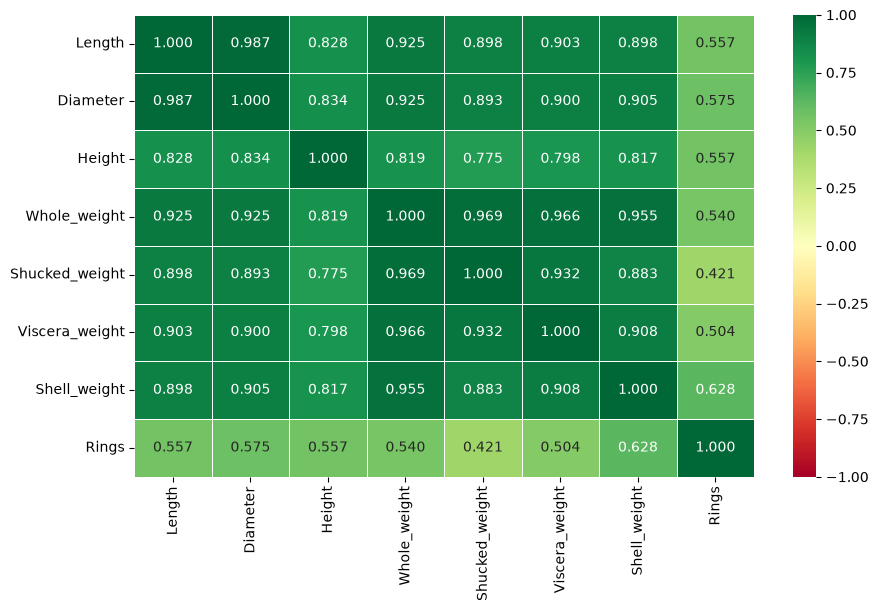

In [10]:
# TODO: Create a correlation matrix for the NUMERICAL features only.
# and NOTE down your observation!
# Hint: Drop the 'Sex' column temporarily or select only numeric columns.
# Optional but recommended: Plot this using sns.heatmap()

plt.subplots(figsize =(10,6))
sns.heatmap(df[['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight','Viscera_weight', 'Shell_weight', 'Rings']].corr(), 
             annot = True, fmt ='.3f', cmap='RdYlGn', linewidth=.5, vmin=-1, vmax=1)
plt.show()
    

In [11]:
df[['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight','Viscera_weight', 'Shell_weight', 'Rings']].corr()

,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
Length,1.000000,0.986812,0.827554,0.925261,0.897914,0.903018,0.897706,0.556720
Diameter,0.986812,1.000000,0.833684,0.925452,0.893162,0.899724,0.905330,0.574660
Height,0.827554,0.833684,1.000000,0.819221,0.774972,0.798319,0.817338,0.557467
Whole_weight,0.925261,0.925452,0.819221,1.000000,0.969405,0.966375,0.955355,0.540390
Shucked_weight,0.897914,0.893162,0.774972,0.969405,1.000000,0.931961,0.882617,0.420884
Viscera_weight,0.903018,0.899724,0.798319,0.966375,0.931961,1.000000,0.907656,0.503819
Shell_weight,0.897706,0.905330,0.817338,0.955355,0.882617,0.907656,1.000000,0.627574
Rings,0.556720,0.574660,0.557467,0.540390,0.420884,0.503819,0.627574,1.000000


## 3. Data Preprocessing
Machine Learning models need numbers, not text. We need to handle the categorical `Sex` column and split our data. 

**Crucial Note for Regularization:** You MUST scale your features when using Ridge, Lasso, or ElasticNet. Because regularization penalizes the size of the coefficients, features on larger scales (like thousands) will be penalized unfairly compared to features on smaller scales (like decimals) if they aren't standardized first.

In [12]:
# TODO: One-hot encode the 'Sex' column using pd.get_dummies() or One-hot Encoding. 
# Hint: Use drop_first=True to avoid the dummy variable trap.

df = pd.get_dummies(df, columns=["Sex"], drop_first=True)

In [14]:
# TODO: Separate your features (X) and target (y)

X = df.drop('Rings', axis=1)
y = df['Rings']

In [15]:
# TODO: Perform a train_test_split. Use a test_size of 0.2 and random_state of 10.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 10)

In [17]:
# TODO: Initialize the StandardScaler
scaler = StandardScaler()

# TODO: Fit the scaler on the training data AND transform X_train. 

X_train_scaled =  scaler.fit_transform(X_train)
# TODO: Transform the test data (Do NOT fit the scaler on the test data!)

X_test_scaled = scaler.transform(X_test)

## 4. Don't Repeat Yourself (DRY): Evaluation Function
As good programmers, we want to avoid writing the same evaluation code four times. 

Write a function that takes in a fitted model, the training data, and the testing data, and prints out the $R^2$ and Root Mean Squared Error (RMSE) for BOTH the training and test sets. Comparing train vs. test metrics helps us spot overfitting!

*__Note__: You can add this to your go-to function toolbox!*

In [26]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name="Model"):
    """
    Predicts and calculates R2 and RMSE for both train and test sets.
    Then prints the Train R2 and RMSE along with the Test R2 and RMSE
    """
    print(f"--- {model_name} Performance ---")
    
    # TODO: Generate predictions for both X_train and X_test
    y_train_pred =model.predict(X_train)
    y_test_pred= model.predict(X_test)
    
    # TODO: Calculate R2 for train and test
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    
    # TODO: Calculate RMSE for train and test (Hint: mean_squared_error(..., squared=False))
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # the hint didnt work as it returned a value error, so i used np.sqrt instead
    # TODO: Print the results clearly
    print('r2 train:', r2_train)
    print('r2 test:', r2_test)
    print('rmse train:', rmse_train)
    print('rmse test:', rmse_test)

## 5. Base Model: Standard Linear Regression
Let's see how a standard linear regression model handles this highly correlated data.

In [27]:
# TODO: Initialize and fit a standard Linear Regression model on the SCALED training data
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)



# TODO: Use your custom evaluate_model() function to check its performance
evaluate_model(lr_model, X_train, X_test, y_train, y_test, model_name="Linear Regression")

--- Linear Regression Performance ---
r2 train: 0.5349186484312887
r2 test: 0.5497455295384085
rmse train: 2.2113127461238995
rmse test: 2.1115883928019126


## 6. Regularization Models
Now, let's apply penalties to our model to handle the multicollinearity.

Instead of guessing the penalty term (`alpha`), we will use Scikit-Learn's built-in Cross-Validation models (`RidgeCV`, `LassoCV`, `ElasticNetCV`). These models automatically try a list of different alphas and select the one that performs best!

### RIDGE REGRESSION (L2 Penalty)

In [28]:
# We provide a list of alphas to test (from very small to very large)
alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]

# TODO: Initialize RidgeCV with the alphas_to_test, cv=5, random_state=10 and fit it to the training data

ridge_model = RidgeCV(alphas=alphas_to_test, cv=5)

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

# TODO: Use evaluate_model() to check performance
evaluate_model(ridge_model, X_train, X_test, y_train, y_test, model_name="Ridge Regression")

# TODO: Print the best alpha found by RidgeCV (Hint: look up the .alpha_ attribute)
print("Best alpha:", ridge_model.alpha_)

--- Ridge Regression Performance ---
r2 train: 0.5319034333447215
r2 test: 0.5447375987209494
rmse train: 2.2184693560402255
rmse test: 2.1232989338107133
Best alpha: 1.0


### LASSO REGRESSION (L1 Penalty)

__Note__: You can provide a custom list to `LassoCV` and `ElasticNetCV` if you want to, but it is generally best practice to leave it blank and let Scikit-Learn automatically calculate the optimal path for you.

In [29]:
# TODO: Initialize LassoCV (you can let it choose alphas automatically by not passing any), cv=5, random_state=10 
# and fit it to the training data

lasso_model = LassoCV(cv=5, random_state = 10)

lasso_model.fit(X_train, y_train)
y_pred_lasso = lasso_model.predict(X_test)

# TODO: Use evaluate_model() to check performance
evaluate_model(lasso_model, X_train, X_test, y_train, y_test, model_name ='Lasso Regression')

# TODO: Print the best alpha found by LassoCV
print("Best alpha (lasso):", lasso_model.alpha_)

--- Lasso Regression Performance ---
r2 train: 0.532214202306055
r2 test: 0.5447365124742469
rmse train: 2.2177328136973653
rmse test: 2.12330146688294
Best alpha (lasso): 0.002455793497744826


### ELASTICNET REGRESSION (L1 + L2 Penalty)

In [30]:
# TODO: Initialize ElasticNetCV with cv=5, random_state=10 and fit it to the training data
elastic_model = ElasticNetCV(cv=5, random_state = 10)

elastic_model.fit(X_train, y_train)
y_pred_elastic = elastic_model.predict(X_test)


# TODO: Use evaluate_model() to check performance

evaluate_model(elastic_model, X_train, X_test, y_train, y_test, model_name ='Elastic Net Regression')

# TODO: Print the best alpha found by ElasticNetCV
print("Best alpha (Elastic):", elastic_model.alpha_)

--- Elastic Net Regression Performance ---
r2 train: 0.5208312679272263
r2 test: 0.5319340637636004
rmse train: 2.244553397215242
rmse test: 2.152949125136615
Best alpha (Elastic): 0.00172455236604418


## 7. Feature Selection with Lasso
One of the superpower traits of Lasso ($L_1$ regularization) is that it can shrink the coefficients of useless or highly correlated features down to **exactly zero**. This acts as automatic feature selection.

Let's look at the coefficients of our models to see this in action.

In [32]:
# Provided Code: Run this cell to compare coefficients!
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Linear_Coef': lr_model.coef_,       # Update 'lr_model' if you named your Linear Regression variable differently
    'Ridge_Coef': ridge_model.coef_,     # Update 'ridge_model' if needed
    'Lasso_Coef': lasso_model.coef_,      # Update 'lasso_model' if needed
    'ElasticNet_Coef': elastic_model.coef_
})

# Display the coefficients
coef_df.round(3)

,Feature,Linear_Coef,Ridge_Coef,Lasso_Coef,ElasticNet_Coef
0,Length,0.169,2.647,0.000,2.978
1,Diameter,9.981,6.312,8.892,4.683
2,Height,10.372,7.381,7.003,4.636
3,Whole_weight,8.959,6.807,7.063,5.138
4,Shucked_weight,-19.771,-17.112,-17.818,-14.057
5,Viscera_weight,-10.352,-6.482,-5.536,-3.059
6,Shell_weight,9.019,10.696,10.722,10.594
7,Sex_I,-0.832,-0.897,-0.865,-0.975
8,Sex_M,0.025,-0.005,0.000,-0.041


__Q1. Which feature(s) did Lasso completely drop (set to 0)?__ 

__Answer:__  Length and Sex_M



__Q2. How does ElasticNet compare to Lasso and Ridge here?__

__Answer:__ Its like the sweet spot, using both L1 and L2 penalties.




## 8. Communicating Results to Stakeholders

**Scenario:** 
Imagine you are presenting these findings to the manager of a seafood fishery. They have no background in data science or math. They want to know if they can trust this model to replace the manual, time-consuming process of cutting abalone shells and counting rings under a microscope. 

**How to phrase your answer:**
When speaking to stakeholders, avoid throwing raw math at them. Translate the metrics into real-world impact. 

*Example using a Real Estate Model:*
*   ❌ **Bad:** "The model has an RMSE of 25000 and an $R^2$ of 0.85."
*   ✅ **Good:** "Our model is highly accurate, capturing about 85% of the factors that drive house prices. When it makes a prediction, it is typically off by about $25,000 on average."

**Your Task:**
Double-click this text cell. Based on your best model's RMSE and $R^2$ scores, write a 3-4 sentence explanation answering the fishery manager's question. Be honest about whether the model is accurate enough to replace humans entirely, or if it should just be used as an estimation tool.
> *# TODO: Write your explanation for the Fishery Manager here...*
>
> Our model is  accurate in capturing about 54% of what drives an abalone's age, and its predictions are typically off by about 2 rings, which translates to roughly 2 years of age.
We'd recommend using it to prioritize which abalones need manual verification and to save time.

# Now it’s your turn!
1. Derive at least one new feature that adds value to the dataset.
2. Apply a feature selection technique to eliminate uninformative variables.
3. Document your reasoning in clean Markdown cells as you go!

In [33]:
df['Meat_Yield_Ratio'] = df['Shucked_weight'] / df['Whole_weight']

In [34]:
df['Meat_Yield_Ratio'].head()

0    0.436770
1    0.441242
2    0.378877
3    0.417636
4    0.436585
Name: Meat_Yield_Ratio, dtype: float64

We will use the lasso model to drop features whose coefficients were regularized to 0.

In [35]:
selected_features = X_train.columns[lasso_model.coef_ != 0]
dropped_features = X_train.columns[lasso_model.coef_ == 0]

print("Selected features:", list(selected_features))
print("Dropped features:", list(dropped_features))

Selected features: ['Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Sex_I']
Dropped features: ['Length', 'Sex_M']


We will then create a linear regression model using the selected features only. As well as check if the R2 and RMSE scores changed after dropping the two features (Length and Sex_M).

In [36]:
X_train_selected = X_train[selected_features]
X_test_selected = X_test[selected_features]

lr_reduced = LinearRegression()
lr_reduced.fit(X_train_selected, y_train)
evaluate_model(lr_reduced, X_train_selected, X_test_selected, y_train, y_test, model_name="Linear Regression (Reduced Features)")

--- Linear Regression (Reduced Features) Performance ---
r2 train: 0.5349074563882678
r2 test: 0.5496276773233155
rmse train: 2.2113393532523196
rmse test: 2.1118647244140343


Interpretation:
The models R2 value is still relatively the same (0.54), so dropping the features(Lenght and Sex_M) truly show that they were not adding predictive value. 
Although a very slight change from the previous Lasso model that had an R2 value of 0.544 and now the new result after dropping the two features show an R2 value of 0.549.